# Optimizing Origin of 850 hPa Temperature

This notebook iterates on the Kansas City 850 hPa temperature-change case from `origin-of-850-temperature-change.ipynb`. It uses ERA5 analyses for March 14, 2017 over the CONUS domain and samples the nearest grid point to Kansas City, Missouri.

The objective is to find a compact, consistent set of ERA5-derived predictors that best explains the hour-by-hour 850 hPa temperature change. This iteration expands the candidate library with split advection components, pressure/height tendencies, wind-field derivatives, gradient magnitudes, and local neighborhood summaries.

The optimizer searches every subset up to six terms, ranks them by leave-one-hour-out mean absolute error, and selects the best subset under the cap. It also reports the smallest subset within 3% of that best score.


In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import os
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 140)
plt.rcParams.update({"figure.dpi": 130})


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "AGENTS.md").exists():
            return path
    return start


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
repo_tmp = PROJECT_ROOT / "tmp"
data_dir = PROJECT_ROOT / "data"
output_dir = repo_tmp / "optimizing-origin-of-850-temperature"
table_output_dir = output_dir / "tables"

for path in [repo_tmp / "matplotlib", data_dir, table_output_dir]:
    path.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(repo_tmp / "matplotlib"))

POINT_NAME = "Kansas City, MO"
POINT_LAT = 39.0997
POINT_LON = -94.5783
ANALYSIS_DATE = "2017-03-14"
ANALYSIS_HOURS = [f"{hour:02d}:00" for hour in range(24)]
CONUS_AREA = [50.0, -125.0, 24.0, -66.0]

MAX_TERMS = 6
SCREEN_TERMS = 16
NEAR_BEST_TOLERANCE = 0.03
RANDOM_SEED = 7

np.random.seed(RANDOM_SEED)

DATA_PATH = data_dir / "era5_conus_850_t_uv_2017-03-14.nc"
VERTICAL_DATA_PATH = data_dir / "era5_conus_825_850_875_t_omega_2017-03-14.nc"
SURFACE_DATA_PATH = data_dir / "era5_conus_surface_pressure_terrain_2017-03-14.nc"
Z850_DATA_PATH = data_dir / "era5_conus_850_geopotential_2017-03-14.nc"

print(f"Point: {POINT_NAME} ({POINT_LAT:.4f}, {POINT_LON:.4f})")
print(f"ERA5 window: {ANALYSIS_DATE} 00:00-23:00 UTC")
print(f"Subset cap: {MAX_TERMS} terms")
print(f"Screened exhaustive candidates: top {SCREEN_TERMS} single terms plus required physical terms")
print(f"Output tables: {table_output_dir.relative_to(PROJECT_ROOT)}")


Point: Kansas City, MO (39.0997, -94.5783)
ERA5 window: 2017-03-14 00:00-23:00 UTC
Subset cap: 6 terms
Screened exhaustive candidates: top 16 single terms plus required physical terms
Output tables: tmp/optimizing-origin-of-850-temperature/tables


## Load The Existing ERA5 Files

This iteration uses the same local ERA5 files already present in `data/`. No CDS request is submitted from this notebook.


In [2]:
required_files = {
    "850 hPa temperature/u/v": DATA_PATH,
    "825/850/875 hPa temperature/omega": VERTICAL_DATA_PATH,
    "surface pressure and terrain": SURFACE_DATA_PATH,
    "850 hPa geopotential": Z850_DATA_PATH,
}
missing = [f"{label}: {path.relative_to(PROJECT_ROOT)}" for label, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required ERA5 files:\n" + "\n".join(missing))


def open_era5_file(path: Path) -> xr.Dataset:
    if zipfile.is_zipfile(path):
        extract_dir = repo_tmp / "era5-extracted" / path.stem
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(path) as archive:
            archive.extractall(extract_dir)
        nc_files = sorted(extract_dir.glob("*.nc"))
        if not nc_files:
            raise FileNotFoundError(f"No NetCDF files found inside {path}")
        return xr.open_dataset(nc_files[0], engine="netcdf4")
    return xr.open_dataset(path, engine="netcdf4")


def normalize_longitudes(ds: xr.Dataset) -> xr.Dataset:
    if "longitude" not in ds.coords:
        return ds
    lon = ds.longitude
    if float(lon.max()) > 180:
        ds = ds.assign_coords(longitude=(((lon + 180) % 360) - 180)).sortby("longitude")
    return ds


def wanted_valid_times() -> pd.DatetimeIndex:
    return pd.date_range(f"{ANALYSIS_DATE} 00:00", f"{ANALYSIS_DATE} 23:00", freq="h")


def select_times(ds: xr.Dataset) -> xr.Dataset:
    ds = normalize_longitudes(ds)
    ds = ds.sel(valid_time=wanted_valid_times())
    return ds.sortby("latitude", ascending=False).sortby("longitude")


def select_850_and_times(ds: xr.Dataset) -> xr.Dataset:
    ds = select_times(ds)
    if "pressure_level" in ds.dims:
        ds = ds.sel(pressure_level=850, method="nearest")
    return ds


def select_vertical_levels_and_times(ds: xr.Dataset) -> xr.Dataset:
    ds = select_times(ds)
    ds = ds.sel(pressure_level=[825, 850, 875], method="nearest")
    return ds.sortby("pressure_level")


era5 = select_850_and_times(open_era5_file(DATA_PATH))
vertical_era5 = select_vertical_levels_and_times(open_era5_file(VERTICAL_DATA_PATH))
surface_era5 = select_times(open_era5_file(SURFACE_DATA_PATH))
z850_era5 = select_850_and_times(open_era5_file(Z850_DATA_PATH))

display(era5)
display(vertical_era5)


<xarray.Dataset> Size: 7MB
Dimensions:         (valid_time: 24, latitude: 105, longitude: 237)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 192B 2017-03-14 ... 2017-03-1...
    expver          (valid_time) <U4 384B ...
  * latitude        (latitude) float64 840B 50.0 49.75 49.5 ... 24.5 24.25 24.0
  * longitude       (longitude) float64 2kB -125.0 -124.8 ... -66.25 -66.0
    number          int64 8B ...
    pressure_level  float64 8B 850.0
Data variables:
    t               (valid_time, latitude, longitude) float32 2MB ...
    u               (valid_time, latitude, longitude) float32 2MB ...
    v               (valid_time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-09T23:28 GRIB to CDM+CF via cfgrib-0.9.1...

<xarray.Dataset> Size: 14MB
Dimensions:         (valid_time: 24, pressure_level: 3, latitude: 105,
                     longitude: 237)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 192B 2017-03-14 ... 2017-03-1...
    expver          (valid_time) <U4 384B ...
  * pressure_level  (pressure_level) float64 24B 825.0 850.0 875.0
  * latitude        (latitude) float64 840B 50.0 49.75 49.5 ... 24.5 24.25 24.0
  * longitude       (longitude) float64 2kB -125.0 -124.8 ... -66.25 -66.0
    number          int64 8B ...
Data variables:
    t               (valid_time, pressure_level, latitude, longitude) float32 7MB ...
    w               (valid_time, pressure_level, latitude, longitude) float32 7MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-10T23:58 GRIB to CDM+CF via cfgrib-0.9.1...

## Build Candidate Terms

The candidate library starts with physical 850 hPa tendency terms, then adds derived predictors that test whether the residual is better explained by flow geometry, pressure-surface behavior, local stability, or small neighborhood context.


In [3]:
R_EARTH_M = 6_371_229.0
SECONDS_PER_HOUR = 3600.0
RD = 287.05
CP = 1004.0
KAPPA = RD / CP
G = 9.80665
P850_PA = 85000.0
P825_PA = 82500.0
P875_PA = 87500.0


def as_time_lat_lon(da: xr.DataArray) -> xr.DataArray:
    drop_dims = [dim for dim in da.dims if dim not in {"valid_time", "latitude", "longitude"}]
    if drop_dims:
        da = da.isel({dim: 0 for dim in drop_dims})
    return da.transpose("valid_time", "latitude", "longitude")


def horizontal_scalar_gradients(da: xr.DataArray) -> tuple[xr.DataArray, xr.DataArray]:
    field = as_time_lat_lon(da)
    lat_rad = np.deg2rad(field.latitude.values)
    lon_rad = np.deg2rad(field.longitude.values)
    cos_lat = np.cos(lat_rad)
    cos_lat = np.where(np.abs(cos_lat) < 1e-6, np.nan, cos_lat)

    d_dlat_rad = np.gradient(field.values, lat_rad, axis=1, edge_order=2)
    d_dlon_rad = np.gradient(field.values, lon_rad, axis=2, edge_order=2)
    d_dy = d_dlat_rad / R_EARTH_M
    d_dx = d_dlon_rad / (R_EARTH_M * cos_lat[None, :, None])

    dx = xr.DataArray(d_dx, coords=field.coords, dims=field.dims)
    dy = xr.DataArray(d_dy, coords=field.coords, dims=field.dims)
    return dx, dy


def interval_hours_for(da: xr.DataArray) -> xr.DataArray:
    hours = (
        pd.to_datetime(da.valid_time.values[1:]) - pd.to_datetime(da.valid_time.values[:-1])
    ).total_seconds() / SECONDS_PER_HOUR
    return xr.DataArray(hours, coords={"valid_time": da.valid_time.values[1:]}, dims="valid_time")


def interval_mean(da: xr.DataArray) -> xr.DataArray:
    start = da.isel(valid_time=slice(None, -1)).assign_coords(valid_time=da.valid_time.values[1:])
    end = da.isel(valid_time=slice(1, None))
    return 0.5 * (start + end)


def interval_integral(da_c_per_hour: xr.DataArray) -> xr.DataArray:
    return interval_mean(da_c_per_hour) * interval_hours_for(da_c_per_hour)


def interval_change(da: xr.DataArray) -> xr.DataArray:
    return da.diff("valid_time").assign_coords(valid_time=da.valid_time.values[1:])


def point_series(da: xr.DataArray, name: str) -> pd.Series:
    point = da.sel(latitude=POINT_LAT, longitude=POINT_LON, method="nearest")
    return pd.Series(np.asarray(point.values).astype(float), index=pd.to_datetime(point.valid_time.values), name=name)


def neighborhood_series(da: xr.DataArray, name: str, radius: int = 1) -> pd.Series:
    field = as_time_lat_lon(da)
    lat_idx = int(np.abs(field.latitude.values - POINT_LAT).argmin())
    lon_idx = int(np.abs(field.longitude.values - POINT_LON).argmin())
    subset = field.isel(
        latitude=slice(max(0, lat_idx - radius), min(field.sizes["latitude"], lat_idx + radius + 1)),
        longitude=slice(max(0, lon_idx - radius), min(field.sizes["longitude"], lon_idx + radius + 1)),
    )
    series = subset.mean(("latitude", "longitude"), skipna=True)
    return pd.Series(np.asarray(series.values).astype(float), index=pd.to_datetime(series.valid_time.values), name=name)


t850_k = as_time_lat_lon(era5["t"])
t850_c = (t850_k - 273.15).rename("t850_C")
u850 = as_time_lat_lon(era5["u"]).rename("u850_mps")
v850 = as_time_lat_lon(era5["v"]).rename("v850_mps")
wind_speed850 = np.hypot(u850, v850).rename("wind_speed850_mps")

vertical_t850_k = vertical_era5["t"].sel(pressure_level=850, method="nearest")
omega850 = as_time_lat_lon(vertical_era5["w"].sel(pressure_level=850, method="nearest")).rename("omega850_Pa_s")
t825_k = as_time_lat_lon(vertical_era5["t"].sel(pressure_level=825, method="nearest"))
t875_k = as_time_lat_lon(vertical_era5["t"].sel(pressure_level=875, method="nearest"))
vertical_gradient_c_per_100hpa = (((t875_k - t825_k) / (P875_PA - P825_PA)) * 10000.0).rename("dTdp_C_per_100hPa")

dtdx, dtdy = horizontal_scalar_gradients(t850_k)
dtdx_100km = (dtdx * 100_000.0).rename("dTdx_C_per_100km")
dtdy_100km = (dtdy * 100_000.0).rename("dTdy_C_per_100km")
temp_gradient_mag_100km = (np.hypot(dtdx, dtdy) * 100_000.0).rename("temperature_gradient_mag_C_per_100km")

zonal_advection = (-u850 * dtdx * SECONDS_PER_HOUR).rename("zonal_temperature_advection_C_per_hour")
meridional_advection = (-v850 * dtdy * SECONDS_PER_HOUR).rename("meridional_temperature_advection_C_per_hour")
horizontal_advection = (zonal_advection + meridional_advection).rename("horizontal_advection_C_per_hour")

vertical_advection = (
    -omega850 * ((t875_k - t825_k) / (P875_PA - P825_PA)) * SECONDS_PER_HOUR
).rename("vertical_temperature_advection_C_per_hour")
adiabatic = (KAPPA * as_time_lat_lon(vertical_t850_k) * omega850 / P850_PA * SECONDS_PER_HOUR).rename(
    "adiabatic_warming_cooling_C_per_hour"
)

dudx, dudy = horizontal_scalar_gradients(u850)
dvdx, dvdy = horizontal_scalar_gradients(v850)
divergence = ((dudx + dvdy) * 100_000.0).rename("divergence_1e5_s_inv")
vorticity = ((dvdx - dudy) * 100_000.0).rename("vorticity_1e5_s_inv")
stretching_deformation = dudx - dvdy
shearing_deformation = dvdx + dudy
deformation = (np.hypot(stretching_deformation, shearing_deformation) * 100_000.0).rename("deformation_1e5_s_inv")

surface_pressure_hpa = (as_time_lat_lon(surface_era5["sp"]) / 100.0).rename("surface_pressure_hPa")
terrain_m = (as_time_lat_lon(surface_era5["z"]) / G).rename("terrain_m")
z850_m = (as_time_lat_lon(z850_era5["z"]) / G).rename("z850_height_m")
height_850_agl_m = (z850_m - terrain_m).rename("height_850_agl_m")

nearest = t850_c.sel(latitude=POINT_LAT, longitude=POINT_LON, method="nearest")
print(f"Nearest ERA5 grid point: {float(nearest.latitude):.2f}, {float(nearest.longitude):.2f}")
print("Computed expanded local and neighborhood candidate terms.")


Nearest ERA5 grid point: 39.00, -94.50
Computed expanded local and neighborhood candidate terms.


## Assemble The Hourly Optimization Table

Rows are one-hour intervals ending at `valid_time_utc`. Budget-like terms are interval integrals; state, flow, and gradient terms are interval means; pressure and height change terms are endpoint differences.


In [4]:
point_temperature = point_series(t850_c, "t850_C")
actual_change = point_temperature.diff().dropna().rename("actual_temperature_change_C")
interval_index = actual_change.index

candidate_series = {
    "horizontal_advection_C": point_series(interval_integral(horizontal_advection), "horizontal_advection_C"),
    "zonal_temperature_advection_C": point_series(interval_integral(zonal_advection), "zonal_temperature_advection_C"),
    "meridional_temperature_advection_C": point_series(interval_integral(meridional_advection), "meridional_temperature_advection_C"),
    "vertical_temperature_advection_C": point_series(interval_integral(vertical_advection), "vertical_temperature_advection_C"),
    "adiabatic_warming_cooling_C": point_series(interval_integral(adiabatic), "adiabatic_warming_cooling_C"),
    "omega850_Pa_s": point_series(interval_mean(omega850), "omega850_Pa_s"),
    "omega850_change_Pa_s": point_series(interval_change(omega850), "omega850_change_Pa_s"),
    "u850_mps": point_series(interval_mean(u850), "u850_mps"),
    "v850_mps": point_series(interval_mean(v850), "v850_mps"),
    "wind_speed850_mps": point_series(interval_mean(wind_speed850), "wind_speed850_mps"),
    "wind_speed850_change_mps": point_series(interval_change(wind_speed850), "wind_speed850_change_mps"),
    "dTdx_C_per_100km": point_series(interval_mean(dtdx_100km), "dTdx_C_per_100km"),
    "dTdy_C_per_100km": point_series(interval_mean(dtdy_100km), "dTdy_C_per_100km"),
    "temperature_gradient_mag_C_per_100km": point_series(interval_mean(temp_gradient_mag_100km), "temperature_gradient_mag_C_per_100km"),
    "dTdp_C_per_100hPa": point_series(interval_mean(vertical_gradient_c_per_100hpa), "dTdp_C_per_100hPa"),
    "divergence_1e5_s_inv": point_series(interval_mean(divergence), "divergence_1e5_s_inv"),
    "vorticity_1e5_s_inv": point_series(interval_mean(vorticity), "vorticity_1e5_s_inv"),
    "deformation_1e5_s_inv": point_series(interval_mean(deformation), "deformation_1e5_s_inv"),
    "t850_start_C": point_temperature.iloc[:-1].set_axis(interval_index).rename("t850_start_C"),
    "surface_pressure_hPa": point_series(interval_mean(surface_pressure_hpa), "surface_pressure_hPa"),
    "surface_pressure_change_hPa": point_series(interval_change(surface_pressure_hpa), "surface_pressure_change_hPa"),
    "height_850_agl_m": point_series(interval_mean(height_850_agl_m), "height_850_agl_m"),
    "height_850_agl_change_m": point_series(interval_change(height_850_agl_m), "height_850_agl_change_m"),
    "z850_height_m": point_series(interval_mean(z850_m), "z850_height_m"),
    "z850_height_change_m": point_series(interval_change(z850_m), "z850_height_change_m"),
    "local3_horizontal_advection_C": neighborhood_series(interval_integral(horizontal_advection), "local3_horizontal_advection_C"),
    "local3_adiabatic_warming_cooling_C": neighborhood_series(interval_integral(adiabatic), "local3_adiabatic_warming_cooling_C"),
    "local3_omega850_Pa_s": neighborhood_series(interval_mean(omega850), "local3_omega850_Pa_s"),
    "local3_surface_pressure_hPa": neighborhood_series(interval_mean(surface_pressure_hpa), "local3_surface_pressure_hPa"),
    "local5_horizontal_advection_C": neighborhood_series(interval_integral(horizontal_advection), "local5_horizontal_advection_C", radius=2),
    "local5_adiabatic_warming_cooling_C": neighborhood_series(interval_integral(adiabatic), "local5_adiabatic_warming_cooling_C", radius=2),
}

feature_table = pd.concat([actual_change, *candidate_series.values()], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
feature_table.index.name = "valid_time_utc"

physical_terms = [
    "horizontal_advection_C",
    "vertical_temperature_advection_C",
    "adiabatic_warming_cooling_C",
]
feature_table["physical_budget_sum_C"] = feature_table[physical_terms].sum(axis=1)
feature_table["physical_budget_residual_C"] = (
    feature_table["actual_temperature_change_C"] - feature_table["physical_budget_sum_C"]
)

candidate_columns = list(candidate_series)

candidate_path = table_output_dir / "candidate_feature_matrix.csv"
feature_table.reset_index().to_csv(candidate_path, index=False)
print(f"Candidate count: {len(candidate_columns)}")
print(f"Saved candidate matrix: {candidate_path.relative_to(PROJECT_ROOT)}")
display(feature_table.round(3).head())


Candidate count: 31
Saved candidate matrix: tmp/optimizing-origin-of-850-temperature/tables/candidate_feature_matrix.csv


,actual_temperature_change_C,horizontal_advection_C,zonal_temperature_advection_C,meridional_temperature_advection_C,vertical_temperature_advection_C,adiabatic_warming_cooling_C,omega850_Pa_s,omega850_change_Pa_s,u850_mps,v850_mps,wind_speed850_mps,wind_speed850_change_mps,dTdx_C_per_100km,dTdy_C_per_100km,temperature_gradient_mag_C_per_100km,dTdp_C_per_100hPa,divergence_1e5_s_inv,vorticity_1e5_s_inv,deformation_1e5_s_inv,t850_start_C,surface_pressure_hPa,surface_pressure_change_hPa,height_850_agl_m,height_850_agl_change_m,z850_height_m,z850_height_change_m,local3_horizontal_advection_C,local3_adiabatic_warming_cooling_C,local3_omega850_Pa_s,local3_surface_pressure_hPa,local5_horizontal_advection_C,local5_adiabatic_warming_cooling_C,physical_budget_sum_C,physical_budget_residual_C
valid_time_utc,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-03-14 01:00:00,-0.389,-0.438,0.007,-0.445,0.105,0.255,0.080,0.043,0.609,-6.328,6.368,-0.883,-0.188,-1.913,1.949,-3.645,-0.529,0.350,4.063,-9.637,990.662,0.471,1197.472,1.840,1483.844,1.840,-0.377,0.268,0.084,991.349,-0.347,0.246,-0.077,-0.312
2017-03-14 02:00:00,-0.595,-0.220,0.034,-0.254,0.085,0.209,0.066,-0.072,1.471,-5.356,5.591,-0.671,-0.590,-1.312,1.447,-3.554,-1.245,0.890,4.077,-10.025,991.074,0.354,1198.995,1.204,1485.366,1.204,-0.186,0.200,0.063,991.762,-0.197,0.161,0.074,-0.669
2017-03-14 03:00:00,-0.699,-0.168,0.095,-0.263,0.010,0.021,0.006,-0.047,2.169,-4.654,5.140,-0.230,-1.184,-1.588,1.988,-3.146,-1.128,2.199,3.331,-10.621,991.487,0.471,1200.765,2.337,1487.136,2.337,-0.148,0.021,0.006,992.175,-0.171,0.006,-0.137,-0.561
2017-03-14 04:00:00,-0.522,-0.201,0.138,-0.339,0.012,0.047,0.015,0.063,2.225,-4.620,5.131,0.212,-1.722,-2.034,2.665,-2.646,-0.425,3.621,2.834,-11.319,991.980,0.517,1203.226,2.585,1489.597,2.585,-0.185,0.055,0.017,992.665,-0.207,0.045,-0.143,-0.379
2017-03-14 05:00:00,-0.216,-0.297,0.132,-0.429,0.054,0.170,0.054,0.015,1.942,-4.916,5.289,0.104,-1.901,-2.419,3.078,-2.748,0.541,4.359,2.671,-11.841,992.313,0.149,1204.400,-0.237,1490.771,-0.237,-0.277,0.196,0.062,992.996,-0.285,0.186,-0.073,-0.143


## Baselines

The fixed physical budget uses coefficient 1.0 on the three tendency terms from the source notebook. The expanded search is judged against this baseline using the same hourly target.


In [5]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 3:
        return {"mae_C": np.inf, "rmse_C": np.inf, "bias_C": np.nan, "r2": np.nan}
    return {
        "mae_C": mean_absolute_error(y_true[mask], y_pred[mask]),
        "rmse_C": float(np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))),
        "bias_C": float(np.mean(y_pred[mask] - y_true[mask])),
        "r2": r2_score(y_true[mask], y_pred[mask]),
    }


y = feature_table["actual_temperature_change_C"].to_numpy()
baseline_rows = []

mean_pred = np.full_like(y, y.mean(), dtype=float)
baseline_rows.append({"model": "intercept_only_mean", **regression_metrics(y, mean_pred)})

physical_pred = feature_table["physical_budget_sum_C"].to_numpy()
baseline_rows.append({"model": "fixed_physical_budget", **regression_metrics(y, physical_pred)})

single_term_rows = []
for term in physical_terms:
    term_pred = feature_table[term].to_numpy()
    single_term_rows.append({"model": term, **regression_metrics(y, term_pred)})

baseline_table = pd.DataFrame([*baseline_rows, *single_term_rows]).sort_values("mae_C")
display(baseline_table.round(3))


,model,mae_C,rmse_C,bias_C,r2
1,fixed_physical_budget,0.212,0.274,0.063,0.768
3,vertical_temperature_advection_C,0.395,0.482,0.167,0.282
4,adiabatic_warming_cooling_C,0.395,0.472,0.358,0.312
0,intercept_only_mean,0.448,0.569,0.000,0.000
2,horizontal_advection_C,0.518,0.662,-0.260,-0.353


## Screened Exhaustive Subset Search

The expanded library is first screened by single-term leave-one-hour-out MAE. The exhaustive search then uses the strongest screened terms plus the physically important tendency terms. This keeps the notebook runnable while still evaluating whether the added variables are better or worse than the first-pass choices.


In [6]:
def loo_predictions(X: pd.DataFrame, y: np.ndarray) -> np.ndarray:
    design = np.column_stack([np.ones(len(X)), X.to_numpy(dtype=float)])
    beta = np.linalg.lstsq(design, y, rcond=None)[0]
    fitted = design @ beta
    residual = y - fitted
    hat_diag = np.diag(design @ np.linalg.pinv(design))
    denom = np.where(np.abs(1.0 - hat_diag) < 1e-9, np.nan, 1.0 - hat_diag)
    loo_residual = residual / denom
    return y - loo_residual


screen_rows = []
for term in candidate_columns:
    pred = loo_predictions(feature_table.loc[:, [term]], y)
    metrics = regression_metrics(y, pred)
    screen_rows.append({"term": term, **{f"single_loo_{key}": value for key, value in metrics.items()}})

screen_table = (
    pd.DataFrame(screen_rows)
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["single_loo_mae_C"])
    .sort_values(["single_loo_mae_C", "term"])
    .reset_index(drop=True)
)

required_terms = [
    "horizontal_advection_C",
    "vertical_temperature_advection_C",
    "adiabatic_warming_cooling_C",
    "dTdx_C_per_100km",
    "surface_pressure_hPa",
]
screened_columns = list(
    dict.fromkeys(
        [
            *required_terms,
            *screen_table.head(SCREEN_TERMS)["term"].tolist(),
        ]
    )
)

screen_path = table_output_dir / "single_term_screen_scores.csv"
screen_table.to_csv(screen_path, index=False)
print(f"Saved single-term screen: {screen_path.relative_to(PROJECT_ROOT)}")
print(f"Exhaustive search candidate count after screening: {len(screened_columns)}")
display(screen_table.head(20).round(3))

score_rows = []
for k in range(1, MAX_TERMS + 1):
    for terms in combinations(screened_columns, k):
        X = feature_table.loc[:, list(terms)]
        pred = loo_predictions(X, y)
        metrics = regression_metrics(y, pred)
        score_rows.append(
            {
                "n_terms": k,
                "terms": " + ".join(terms),
                **{f"loo_{key}": value for key, value in metrics.items()},
            }
        )

score_table = (
    pd.DataFrame(score_rows)
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["loo_mae_C", "loo_rmse_C"])
    .sort_values(["loo_mae_C", "n_terms", "terms"])
    .reset_index(drop=True)
)
best_score = score_table.iloc[0]
best_mae = float(best_score["loo_mae_C"])
selected_terms = best_score["terms"].split(" + ")

near_best = score_table[score_table["loo_mae_C"] <= best_mae * (1.0 + NEAR_BEST_TOLERANCE)]
compact_score = near_best.sort_values(["n_terms", "loo_mae_C", "terms"]).iloc[0]
compact_terms = compact_score["terms"].split(" + ")

score_path = table_output_dir / "subset_search_scores.csv"
score_table.to_csv(score_path, index=False)
print(f"Saved subset scores: {score_path.relative_to(PROJECT_ROOT)}")
print(f"Best leave-one-out MAE: {best_mae:.3f} C")
print(f"Best terms ({len(selected_terms)}): {', '.join(selected_terms)}")
print(
    f"Smallest within {100 * NEAR_BEST_TOLERANCE:.0f}% ({len(compact_terms)}): "
    + ", ".join(compact_terms)
)

display(score_table.head(15).round(3))
display(
    score_table.groupby("n_terms")
    .agg(best_loo_mae_C=("loo_mae_C", "min"), median_loo_mae_C=("loo_mae_C", "median"), subsets=("terms", "count"))
    .reset_index()
    .round(3)
)


Saved single-term screen: tmp/optimizing-origin-of-850-temperature/tables/single_term_screen_scores.csv
Exhaustive search candidate count after screening: 18


,term,single_loo_mae_C,single_loo_rmse_C,single_loo_bias_C,single_loo_r2
0,local3_omega850_Pa_s,0.172,0.230,-0.004,0.837
1,local3_adiabatic_warming_cooling_C,0.172,0.230,-0.004,0.837
2,local5_adiabatic_warming_cooling_C,0.180,0.242,-0.003,0.818
3,adiabatic_warming_cooling_C,0.181,0.230,-0.006,0.836
4,omega850_Pa_s,0.181,0.230,-0.006,0.836
5,surface_pressure_change_hPa,0.324,0.473,0.002,0.309
6,wind_speed850_change_mps,0.356,0.446,0.005,0.385
7,vertical_temperature_advection_C,0.376,0.456,-0.008,0.356
8,dTdx_C_per_100km,0.390,0.467,-0.002,0.325
9,height_850_agl_change_m,0.403,0.524,-0.006,0.151


Saved subset scores: tmp/optimizing-origin-of-850-temperature/tables/subset_search_scores.csv
Best leave-one-out MAE: 0.146 C
Best terms (4): horizontal_advection_C, adiabatic_warming_cooling_C, surface_pressure_hPa, zonal_temperature_advection_C
Smallest within 3% (3): dTdx_C_per_100km, surface_pressure_hPa, local3_adiabatic_warming_cooling_C


,n_terms,terms,loo_mae_C,loo_rmse_C,loo_bias_C,loo_r2
0,4,horizontal_advection_C + adiabatic_warming_cooling_C + surface_pressure_hPa + zonal_temperature_advection_C,0.146,0.222,0.002,0.848
1,4,horizontal_advection_C + surface_pressure_hPa + omega850_Pa_s + zonal_temperature_advection_C,0.146,0.222,0.002,0.847
2,3,dTdx_C_per_100km + surface_pressure_hPa + local3_adiabatic_warming_cooling_C,0.149,0.232,0.002,0.833
3,3,dTdx_C_per_100km + surface_pressure_hPa + local3_omega850_Pa_s,0.150,0.233,0.002,0.833
4,6,horizontal_advection_C + omega850_Pa_s + height_850_agl_change_m + t850_start_C + zonal_temperature_advection_C + dTdy_C_per_100km,0.150,0.216,0.003,0.855
5,6,horizontal_advection_C + omega850_Pa_s + z850_height_change_m + t850_start_C + zonal_temperature_advection_C + dTdy_C_per_100km,0.150,0.216,0.003,0.855
6,6,horizontal_advection_C + adiabatic_warming_cooling_C + height_850_agl_change_m + t850_start_C + zonal_temperature_advection_C + dTdy_C_p...,0.150,0.216,0.003,0.856
7,6,horizontal_advection_C + adiabatic_warming_cooling_C + z850_height_change_m + t850_start_C + zonal_temperature_advection_C + dTdy_C_per_...,0.150,0.216,0.003,0.856
8,6,horizontal_advection_C + adiabatic_warming_cooling_C + surface_pressure_hPa + omega850_Pa_s + surface_pressure_change_hPa + wind_speed85...,0.151,0.232,-0.008,0.834
9,3,adiabatic_warming_cooling_C + dTdx_C_per_100km + surface_pressure_hPa,0.152,0.223,0.001,0.846


,n_terms,best_loo_mae_C,median_loo_mae_C,subsets
0,1,0.172,0.397,18
1,2,0.164,0.293,153
2,3,0.149,0.197,816
3,4,0.146,0.197,3060
4,5,0.153,0.199,8568
5,6,0.150,0.204,18564


## Refit The Selected Model And Write Hour-By-Hour Attribution

The selected terms are fit once on the full set of hourly intervals for the final attribution table. The cross-validation score above is the conservative model-selection score.


In [7]:
def fit_scaled_linear_model(terms: list[str]):
    X = feature_table.loc[:, terms]
    model = make_pipeline(StandardScaler(), LinearRegression())
    model.fit(X, y)
    pred = model.predict(X)
    scaler = model.named_steps["standardscaler"]
    linear = model.named_steps["linearregression"]
    coef = pd.DataFrame(
        {
            "term": terms,
            "standardized_coefficient_C": linear.coef_,
            "mean": scaler.mean_,
            "scale": scaler.scale_,
        }
    ).sort_values("standardized_coefficient_C", key=lambda s: s.abs(), ascending=False)
    return model, pred, coef


selected_model, optimized_pred, coef_table = fit_scaled_linear_model(selected_terms)
compact_model, compact_pred, compact_coef_table = fit_scaled_linear_model(compact_terms)

attribution_table = feature_table.reset_index().copy()
attribution_table["optimized_prediction_C"] = optimized_pred
attribution_table["optimized_residual_C"] = (
    attribution_table["actual_temperature_change_C"] - attribution_table["optimized_prediction_C"]
)
attribution_table["compact_prediction_C"] = compact_pred
attribution_table["compact_residual_C"] = (
    attribution_table["actual_temperature_change_C"] - attribution_table["compact_prediction_C"]
)
attribution_table["fixed_physical_budget_prediction_C"] = attribution_table["physical_budget_sum_C"]
attribution_table["fixed_physical_budget_residual_C"] = (
    attribution_table["actual_temperature_change_C"] - attribution_table["fixed_physical_budget_prediction_C"]
)
attribution_table["selected_terms"] = " + ".join(selected_terms)
attribution_table["compact_terms"] = " + ".join(compact_terms)

selected_metrics = regression_metrics(y, optimized_pred)
compact_metrics = regression_metrics(y, compact_pred)
physical_metrics = regression_metrics(y, attribution_table["fixed_physical_budget_prediction_C"].to_numpy())
metric_summary = pd.DataFrame(
    [
        {"model": "selected_refit", "n_terms": len(selected_terms), **selected_metrics},
        {"model": "selected_leave_one_out", "n_terms": len(selected_terms), "mae_C": best_score["loo_mae_C"], "rmse_C": best_score["loo_rmse_C"], "bias_C": best_score["loo_bias_C"], "r2": best_score["loo_r2"]},
        {"model": "compact_refit", "n_terms": len(compact_terms), **compact_metrics},
        {"model": "compact_leave_one_out", "n_terms": len(compact_terms), "mae_C": compact_score["loo_mae_C"], "rmse_C": compact_score["loo_rmse_C"], "bias_C": compact_score["loo_bias_C"], "r2": compact_score["loo_r2"]},
        {"model": "fixed_physical_budget", "n_terms": len(physical_terms), **physical_metrics},
    ]
)

attribution_path = table_output_dir / "optimized_hourly_temperature_attribution.csv"
coef_path = table_output_dir / "selected_model_coefficients.csv"
compact_coef_path = table_output_dir / "compact_model_coefficients.csv"
metrics_path = table_output_dir / "selected_model_metrics.csv"
attribution_table.to_csv(attribution_path, index=False)
coef_table.to_csv(coef_path, index=False)
compact_coef_table.to_csv(compact_coef_path, index=False)
metric_summary.to_csv(metrics_path, index=False)

print(f"Saved attribution table: {attribution_path.relative_to(PROJECT_ROOT)}")
print(f"Saved selected coefficients: {coef_path.relative_to(PROJECT_ROOT)}")
print(f"Saved compact coefficients: {compact_coef_path.relative_to(PROJECT_ROOT)}")
print(f"Saved metrics: {metrics_path.relative_to(PROJECT_ROOT)}")
display(metric_summary.round(3))
display(coef_table.round(4))
display(
    attribution_table[
        [
            "valid_time_utc",
            "actual_temperature_change_C",
            "optimized_prediction_C",
            "optimized_residual_C",
            "compact_prediction_C",
            "compact_residual_C",
            "fixed_physical_budget_prediction_C",
            "fixed_physical_budget_residual_C",
            *selected_terms,
        ]
    ].round(3)
)


Saved attribution table: tmp/optimizing-origin-of-850-temperature/tables/optimized_hourly_temperature_attribution.csv
Saved selected coefficients: tmp/optimizing-origin-of-850-temperature/tables/selected_model_coefficients.csv
Saved compact coefficients: tmp/optimizing-origin-of-850-temperature/tables/compact_model_coefficients.csv
Saved metrics: tmp/optimizing-origin-of-850-temperature/tables/selected_model_metrics.csv


,model,n_terms,mae_C,rmse_C,bias_C,r2
0,selected_refit,4,0.116,0.181,-0.000,0.899
1,selected_leave_one_out,4,0.146,0.222,0.002,0.848
2,compact_refit,3,0.125,0.196,-0.000,0.882
3,compact_leave_one_out,3,0.149,0.232,0.002,0.833
4,fixed_physical_budget,3,0.212,0.274,0.063,0.768


,term,standardized_coefficient_C,mean,scale
1,adiabatic_warming_cooling_C,0.4700,0.2572,0.3066
3,zonal_temperature_advection_C,0.1620,0.0483,0.1468
2,surface_pressure_hPa,0.1524,992.7597,1.3184
0,horizontal_advection_C,-0.0657,-0.3610,0.1445


/tmp/ipykernel_535032/3985520640.py:79: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(3)


,valid_time_utc,actual_temperature_change_C,optimized_prediction_C,optimized_residual_C,compact_prediction_C,compact_residual_C,fixed_physical_budget_prediction_C,fixed_physical_budget_residual_C,horizontal_advection_C,adiabatic_warming_cooling_C,surface_pressure_hPa,zonal_temperature_advection_C
0,2017-03-14 01:00:00,-0.389,-0.357,-0.032,-0.382,-0.007,-0.077,-0.312,-0.438,0.255,990.662,0.007
1,2017-03-14 02:00:00,-0.595,-0.449,-0.146,-0.429,-0.166,0.074,-0.669,-0.220,0.209,991.074,0.034
2,2017-03-14 03:00:00,-0.699,-0.646,-0.052,-0.630,-0.069,-0.137,-0.561,-0.168,0.021,991.487,0.095
3,2017-03-14 04:00:00,-0.522,-0.487,-0.034,-0.503,-0.019,-0.143,-0.379,-0.201,0.047,991.980,0.138
4,2017-03-14 05:00:00,-0.216,-0.222,0.007,-0.252,0.036,-0.073,-0.143,-0.297,0.170,992.313,0.132
5,2017-03-14 06:00:00,-0.038,0.043,-0.081,0.029,-0.067,0.074,-0.111,-0.350,0.301,992.276,0.173
6,2017-03-14 07:00:00,0.293,0.281,0.012,0.261,0.031,0.170,0.123,-0.413,0.395,992.020,0.259
7,2017-03-14 08:00:00,0.301,0.399,-0.099,0.371,-0.070,0.144,0.156,-0.531,0.430,991.797,0.291
8,2017-03-14 09:00:00,0.670,0.667,0.003,0.665,0.005,0.418,0.252,-0.597,0.606,991.589,0.285
9,2017-03-14 10:00:00,0.964,0.997,-0.033,0.991,-0.027,0.965,-0.001,-0.530,0.871,991.308,0.273


## Visual Check

The plots compare the actual hourly change with the selected optimized model, the compact near-best model, and the fixed physical budget.


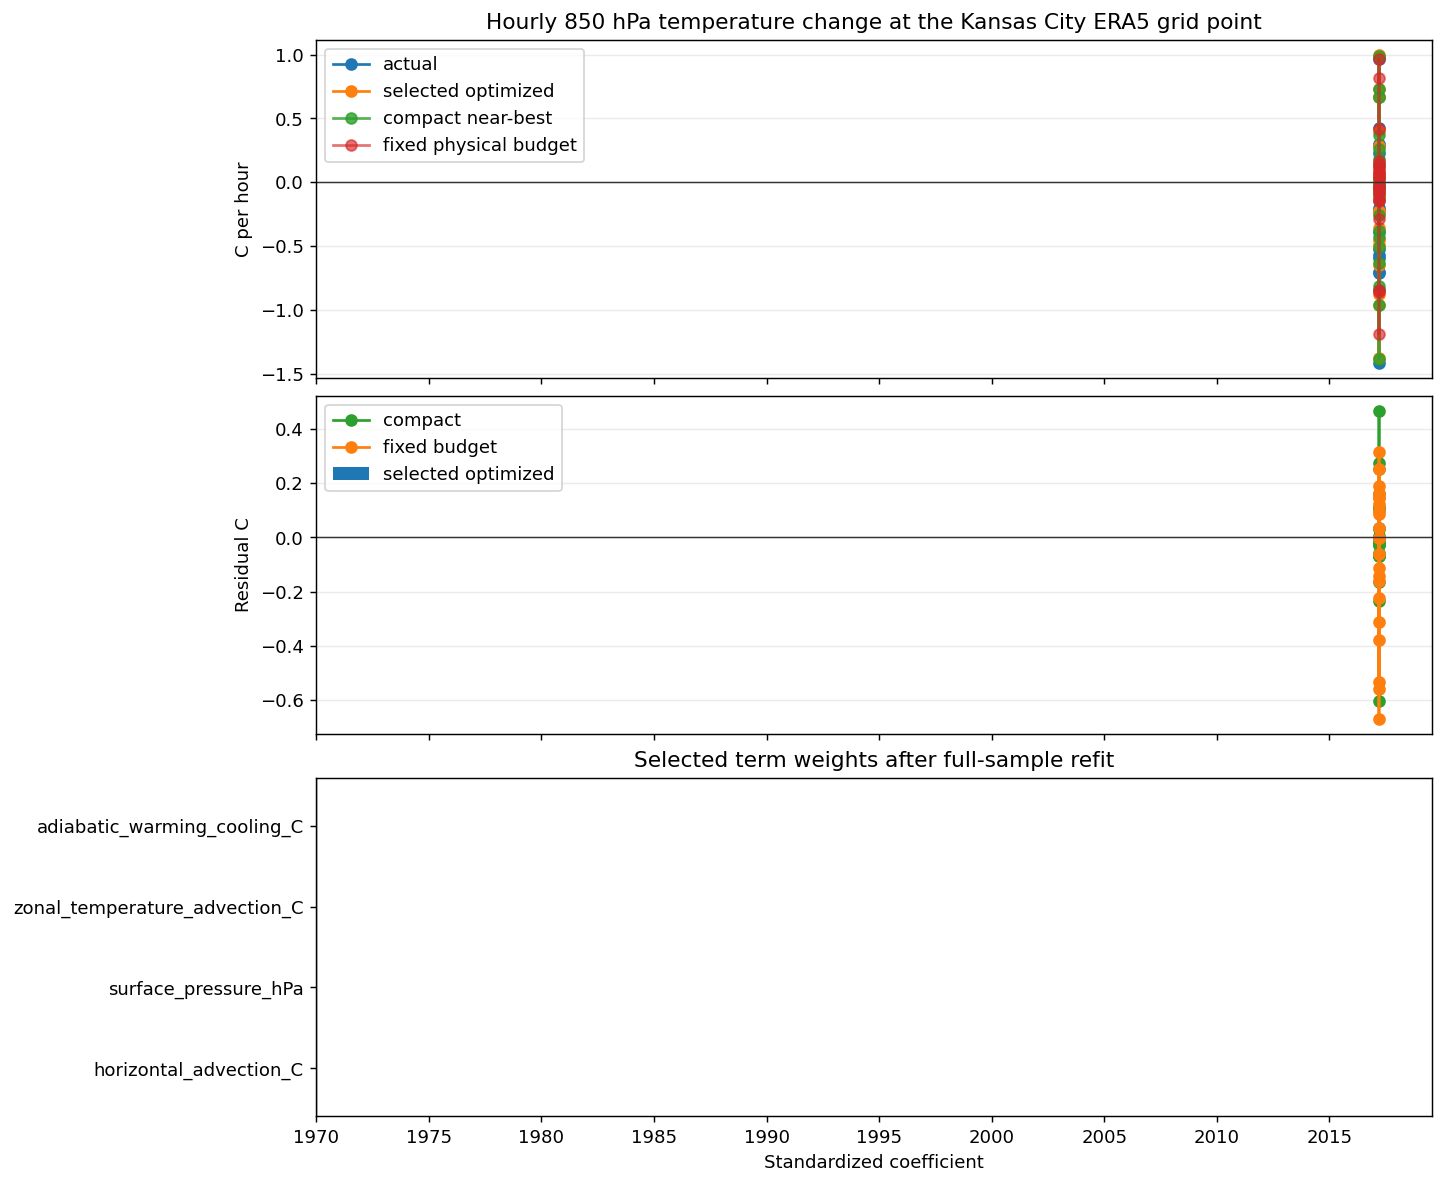

In [8]:
plot_df = attribution_table.copy()
plot_df["valid_time_utc"] = pd.to_datetime(plot_df["valid_time_utc"])

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, constrained_layout=True)

axes[0].plot(plot_df["valid_time_utc"], plot_df["actual_temperature_change_C"], marker="o", label="actual")
axes[0].plot(plot_df["valid_time_utc"], plot_df["optimized_prediction_C"], marker="o", label="selected optimized")
axes[0].plot(plot_df["valid_time_utc"], plot_df["compact_prediction_C"], marker="o", label="compact near-best", alpha=0.8)
axes[0].plot(
    plot_df["valid_time_utc"],
    plot_df["fixed_physical_budget_prediction_C"],
    marker="o",
    label="fixed physical budget",
    alpha=0.65,
)
axes[0].axhline(0, color="0.2", linewidth=0.8)
axes[0].set_ylabel("C per hour")
axes[0].set_title("Hourly 850 hPa temperature change at the Kansas City ERA5 grid point")
axes[0].legend(loc="best")

axes[1].bar(plot_df["valid_time_utc"], plot_df["optimized_residual_C"], width=0.035, label="selected optimized")
axes[1].plot(plot_df["valid_time_utc"], plot_df["compact_residual_C"], color="tab:green", marker="o", label="compact")
axes[1].plot(
    plot_df["valid_time_utc"],
    plot_df["fixed_physical_budget_residual_C"],
    color="tab:orange",
    marker="o",
    label="fixed budget",
)
axes[1].axhline(0, color="0.2", linewidth=0.8)
axes[1].set_ylabel("Residual C")
axes[1].legend(loc="best")

coef_plot = coef_table.sort_values("standardized_coefficient_C")
axes[2].barh(coef_plot["term"], coef_plot["standardized_coefficient_C"])
axes[2].axvline(0, color="0.2", linewidth=0.8)
axes[2].set_xlabel("Standardized coefficient")
axes[2].set_title("Selected term weights after full-sample refit")

for ax in axes[:2]:
    ax.grid(True, axis="y", alpha=0.25)

display(fig)
plt.close(fig)


## What Improved And What Got Worse

This cell compares the expanded search with the fixed physical budget and records which added variable families helped.


In [9]:
selected_loo = metric_summary.query("model == 'selected_leave_one_out'").iloc[0]
compact_loo = metric_summary.query("model == 'compact_leave_one_out'").iloc[0]
selected_refit = metric_summary.query("model == 'selected_refit'").iloc[0]
physical_refit = metric_summary.query("model == 'fixed_physical_budget'").iloc[0]

best_by_n = score_table.groupby("n_terms").agg(best_loo_mae_C=("loo_mae_C", "min")).reset_index()
improvement_vs_fixed_refit = 100.0 * (physical_refit["mae_C"] - selected_refit["mae_C"]) / physical_refit["mae_C"]
loo_improvement_vs_fixed_refit = 100.0 * (physical_refit["mae_C"] - selected_loo["mae_C"]) / physical_refit["mae_C"]
compact_penalty = 100.0 * (compact_loo["mae_C"] - selected_loo["mae_C"]) / selected_loo["mae_C"]

print("Best selected terms:")
for term in selected_terms:
    print(f"- {term}")
print()
print("Compact near-best terms:")
for term in compact_terms:
    print(f"- {term}")
print()
print(
    f"Selected leave-one-out MAE is {selected_loo['mae_C']:.3f} C with {len(selected_terms)} terms; "
    f"compact leave-one-out MAE is {compact_loo['mae_C']:.3f} C with {len(compact_terms)} terms "
    f"({compact_penalty:.1f}% higher)."
)
print(
    f"Full-sample optimized MAE is {selected_refit['mae_C']:.3f} C versus "
    f"{physical_refit['mae_C']:.3f} C for the fixed physical budget "
    f"({improvement_vs_fixed_refit:.1f}% lower)."
)
print(
    f"Using the conservative leave-one-out score, the selected model is "
    f"{loo_improvement_vs_fixed_refit:.1f}% lower MAE than the fixed physical budget's full-sample error."
)
print()
print("Best score by number of terms:")
display(best_by_n.round(3))

top_terms = " + ".join(selected_terms)
if any("change" in term for term in selected_terms):
    print("Pressure/height/change variables helped in the best subset.")
else:
    print("Pressure/height/change variables were tested, but the best subset did not need them.")
if any(term in selected_terms for term in ["divergence_1e5_s_inv", "vorticity_1e5_s_inv", "deformation_1e5_s_inv"]):
    print("Wind-derivative variables helped in the best subset.")
else:
    print("Divergence/vorticity/deformation were tested and were not retained in the best subset.")
if any(term.startswith("local") for term in selected_terms):
    print("Neighborhood-mean variables helped in the best subset.")
else:
    print("Neighborhood-mean variables were tested and were not retained in the best subset.")


Best selected terms:
- horizontal_advection_C
- adiabatic_warming_cooling_C
- surface_pressure_hPa
- zonal_temperature_advection_C

Compact near-best terms:
- dTdx_C_per_100km
- surface_pressure_hPa
- local3_adiabatic_warming_cooling_C

Selected leave-one-out MAE is 0.146 C with 4 terms; compact leave-one-out MAE is 0.149 C with 3 terms (2.3% higher).
Full-sample optimized MAE is 0.116 C versus 0.212 C for the fixed physical budget (45.0% lower).
Using the conservative leave-one-out score, the selected model is 31.0% lower MAE than the fixed physical budget's full-sample error.

Best score by number of terms:


,n_terms,best_loo_mae_C
0,1,0.172
1,2,0.164
2,3,0.149
3,4,0.146
4,5,0.153
5,6,0.150


Pressure/height/change variables were tested, but the best subset did not need them.
Divergence/vorticity/deformation were tested and were not retained in the best subset.
Neighborhood-mean variables were tested and were not retained in the best subset.


## Further ERA5 Variables Worth Testing

This run intentionally avoids a new CDS download. The local files suggest the next useful ERA5 expansion would be a vertical stack rather than more single-level variants: 700/925 hPa temperature, wind, omega, humidity, and geopotential. That would let the optimizer test layer-mean advection, thermal-wind structure, lower-tropospheric static stability, and diabatic/moist-process proxies against the remaining residual.
